In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.cm import get_cmap
from scipy.special import roots_gegenbauer
import matplotlib
import matplotlib.dates as mdates 
from scipy.special import eval_gegenbauer
import datetime

# Gegenbauer polynomials : weighing functions

/tmp/ipykernel_3164/3671467296.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("coolwarm")
/tmp/ipykernel_3164/3671467296.py:16: RuntimeWarning: divide by zero encountered in power
  w = (1 - x**2)**(a - 0.5)


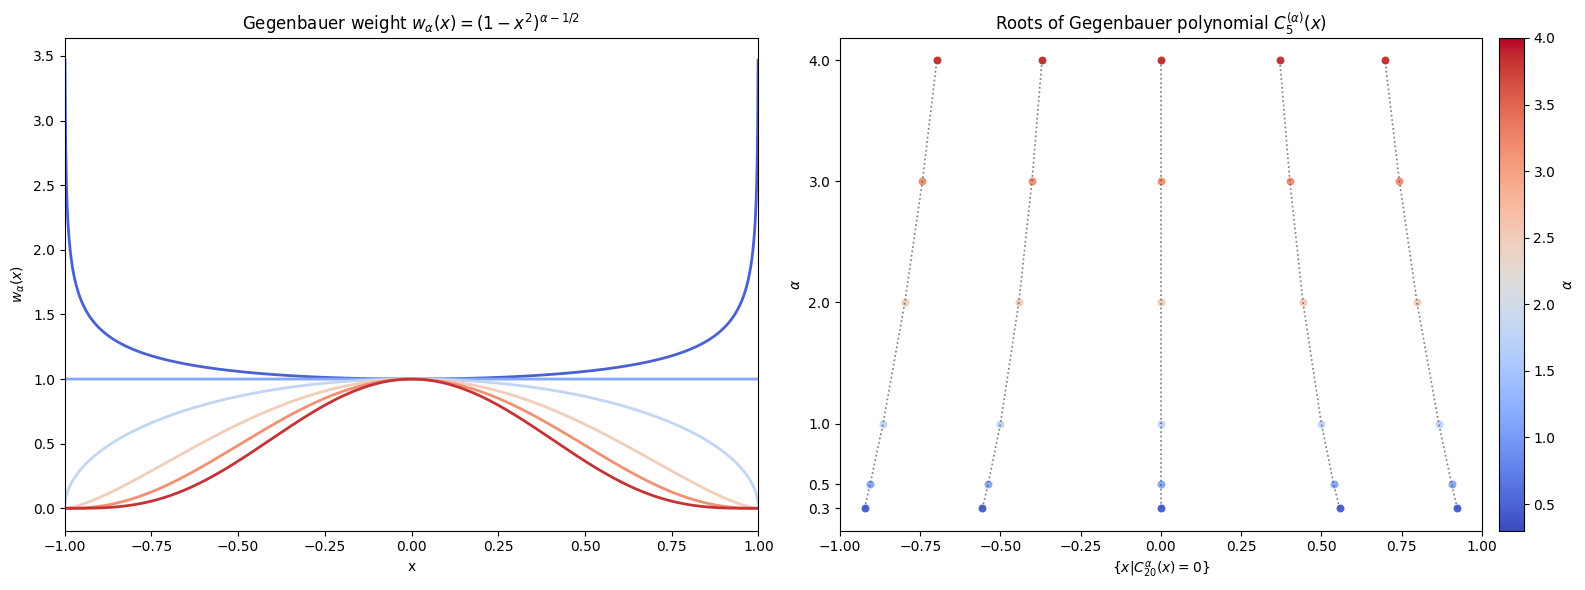

In [7]:
# Parameters
alphas = np.array([0.3, 0.5, 1.0, 2.0, 3.0, 4.0], dtype=float)
n = 5  # degree for showing root locations

# Grid on [-1,1]
x = np.linspace(-1, 1, 2001)

# Colormap
cmap = get_cmap("coolwarm")
colors = cmap(np.linspace(0.05, 0.95, len(alphas)))

fig, (ax_w, ax_r) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Weight functions: w_alpha(x) = (1-x^2)^(alpha-1/2) ----
for a, c in zip(alphas, colors):
    w = (1 - x**2)**(a - 0.5)
    ax_w.plot(x, w, lw=2, color=c, label=fr"$\alpha={a:g}$")

ax_w.set_title(r"Gegenbauer weight $w_\alpha(x)=(1-x^2)^{\alpha-1/2}$")
ax_w.set_xlabel("x")
ax_w.set_ylabel(r"$w_\alpha(x)$")
ax_w.set_xlim(-1, 1)
# ax_w.set_yscale("log")  # highlights endpoint behavior
# ax_w.grid(True, alpha=0.3)
# ax_w.legend(frameon=False)

# ---- Root distributions for C_n^(alpha) ----
# Store roots so we can connect same-index roots across alphas
roots_by_alpha = []
for a in alphas:
    r, _ = roots_gegenbauer(n, a)
    roots_by_alpha.append(r)
roots_by_alpha = np.vstack(roots_by_alpha)  # shape: (len(alphas), n)

# Scatter of roots for each alpha
for a, c, r in zip(alphas, colors, roots_by_alpha):
    ax_r.scatter(r, np.full_like(r, a), s=22, color=c)

# Dotted "tracks": connect root k across alpha values
# (these show how each root moves as alpha increases)
for k in range(n):
    ax_r.plot(roots_by_alpha[:, k], alphas, ls=":", lw=1.2, color="0.35", alpha=0.8)

ax_r.set_title(fr"Roots of Gegenbauer polynomial $C_{{{n}}}^{{(\alpha)}}(x)$")
ax_r.set_xlabel(r"$\left\{ x | C_{20}^{\alpha}(x) = 0 \right\}$")
ax_r.set_ylabel(r"$\alpha$")
ax_r.set_xlim(-1, 1)
ax_r.set_yticks(alphas)
# ax_r.grid(True, alpha=0.3)

# Optional: colorbar to emphasize mapping alpha<->color
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=alphas.min(), vmax=alphas.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_r, fraction=0.05, pad=0.025)
cbar.set_label(r"$\alpha$")

plt.tight_layout()
plt.savefig('./gegenbauer_roots_weights.png', dpi = 300, transparent = True, bbox_inches ='tight')

# Gegenbauer decomposition of the liquidity curve

In [16]:
def gegenbauer_vander(x, deg, alpha):
    if alpha <= -0.5:
        raise ValueError("Require alpha > -0.5.")
    x = np.asarray(x, float)
    return np.column_stack([eval_gegenbauer(n, alpha, x) for n in range(deg + 1)])

def orthopoly_decompose(
    Ylog,                 # array-like (n_t, n_ticks) OR pd.DataFrame with tick columns
    x_norm,               # array-like (n_ticks,), must be in [-1, 1]
    deg=5,                # highest degree; number of factors = deg+1
    center_time=True,     # subtract m(x) across time (like PCA centering)
    ridge=1e-10,          # small ridge for numerical stability
    index=None, 
    alpha = 0.5,          # optional time index if Ylog is ndarray
):
    if isinstance(Ylog, pd.DataFrame):
        Y = Ylog.to_numpy(dtype=float)
        if index is None:
            index = Ylog.index
    else:
        Y = np.asarray(Ylog, dtype=float)
        if index is None:
            index = pd.RangeIndex(Y.shape[0])

    x = np.asarray(x_norm, dtype=float)
    if np.any(x < -1 - 1e-12) or np.any(x > 1 + 1e-12):
        raise ValueError("x_norm must lie in [-1,1].")

    n_t, n_ticks = Y.shape
    if x.shape[0] != n_ticks:
        raise ValueError("x_norm length must match n_ticks (number of columns in Ylog).")

    # --- mean curve and centering (matches the paper's 'centered data' assumption)
    if center_time:
        m = Y.mean(axis=0)
        X = Y - m
    else:
        m = np.zeros(n_ticks)
        X = Y

    
    Phi = gegenbauer_vander(x, deg, alpha)   # (n_ticks, deg+1)
    basis_name = f"Gegenbauer_{alpha}"

    # --- solve for coefficients B in least squares sense for all t:
    # X ≈ B Phi^T  ->  B = X Phi (Phi^T Phi)^{-1}
    G = Phi.T @ Phi
    G = G + ridge * np.eye(G.shape[0])
    Ginv = np.linalg.inv(G)

    B = (X @ Phi) @ Ginv               # (n_t, deg+1)
    Yhat = (B @ Phi.T) + m             # (n_t, n_ticks)
    R = Y - Yhat

    # package coefficients as DataFrame for convenient "score through time"
    cols = [f"{basis_name}_deg{j}" for j in range(deg + 1)]
    B_df = pd.DataFrame(B, index=index, columns=cols)

    return m, B_df, Phi, Yhat, R


def gegenbauer_scores(Ylog, x_norm, deg=5, alpha=0.5, center_time=True, ridge=1e-10):
    mG, B_gegen, Phi_gegen, Yhat_gegen, R_gegen = orthopoly_decompose(
        Ylog, x_norm, deg=deg, center_time=center_time, ridge=ridge, alpha=alpha
    )
    return B_gegen, Yhat_gegen, R_gegen, mG, Phi_gegen

def plot_shocks(gegen_scores, m, phi, Ylog, alpha, i):
    fig, axs = plt.subplots(3,2, figsize=(12, 12))
    bs = gegen_scores.iloc[-1,:].values
    std = gegen_scores.std(axis = 0).values
    for k in range(6):
        axs[k//2, k%2].plot(bs @ phi.T + m, color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i]+0.2), lw=2, label = 'Yhat')
        bsp = bs.copy()
        bsp[k]+=std[k]  
        axs[k//2, k%2].plot(bsp @ phi.T + m, color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i] + 0.4), lw=2, label = '+1 std')
        bsp[k]-=2*std[k]  
        axs[k//2, k%2].plot(bsp @ phi.T + m, color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i]), lw=2, label = '-1 std')
        axs[k//2, k%2].plot(Ylog.iloc[-1,:].values, '--', alpha=0.5, label = 'Actual', color = 'black')
        axs[k//2, k%2].set_title(r'Shock $\beta_{}$'.format(k), fontsize = 10)
    plt.legend(ncols=4, frameon=False, bbox_to_anchor=(0.5, -0.2))
    fig.suptitle(r'Gegenbauer Basis Shocks ($\alpha={}$)'.format(alpha), fontsize = 14)
    plt.savefig(f'./gegenbauer_shocks_alpha{alpha}.png', dpi=300, transparent = True, bbox_inches = 'tight')


In [17]:
df = pd.read_parquet('hourly_liquidity_full.parquet')
def transform_df(df, centered, TT, TT_end):
    d = df[df.hour > TT]
    d = d[d.hour <= TT_end]
    d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True, unit = 's')
    if centered:
        WINDOW = 50
        d["tick_norm"] = (d["tickLower"].astype(float) - 0.0) / WINDOW
        d["tick_norm"] = d["tick_norm"].clip(-1, 1)
    else:
        WINDOW = 50
        d["tick_norm"] = (d["tickLower"].astype(float) - d['poolTick'].astype(float)) / WINDOW
        d["tick_norm"] = d["tick_norm"].clip(-1, 1)

    # Log liquidity (use log1p to handle zeros)
    d["logL"] = np.log1p(d["active_liquidity_L"].astype(float))
    return d
TT = datetime.datetime(2022,11,1,0, tzinfo=datetime.timezone.utc)
TT_end = df.hour.iloc[-1]

d_pegcentered = transform_df(df, centered=True, TT=TT, TT_end=TT_end)


LIQ_COL = "active_liquidity_L"            
Y_pegcentered = (d_pegcentered.pivot_table(index="timestamp", columns="tick_norm", values=LIQ_COL, aggfunc="sum")
       .sort_index()
       .sort_index(axis=1))
Y_pegcentered = Y_pegcentered.fillna(0.0)
Ylog_pegcentered = np.log1p(Y_pegcentered)


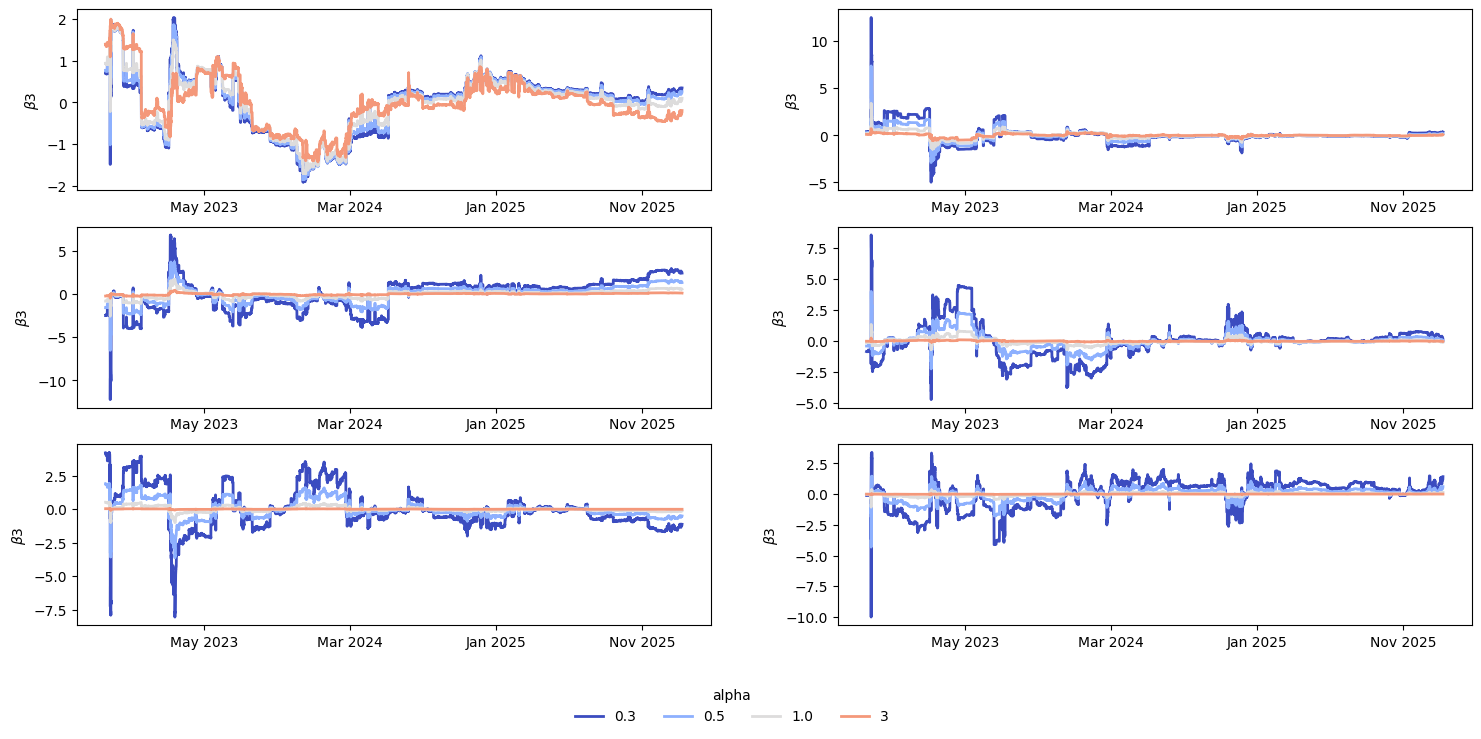

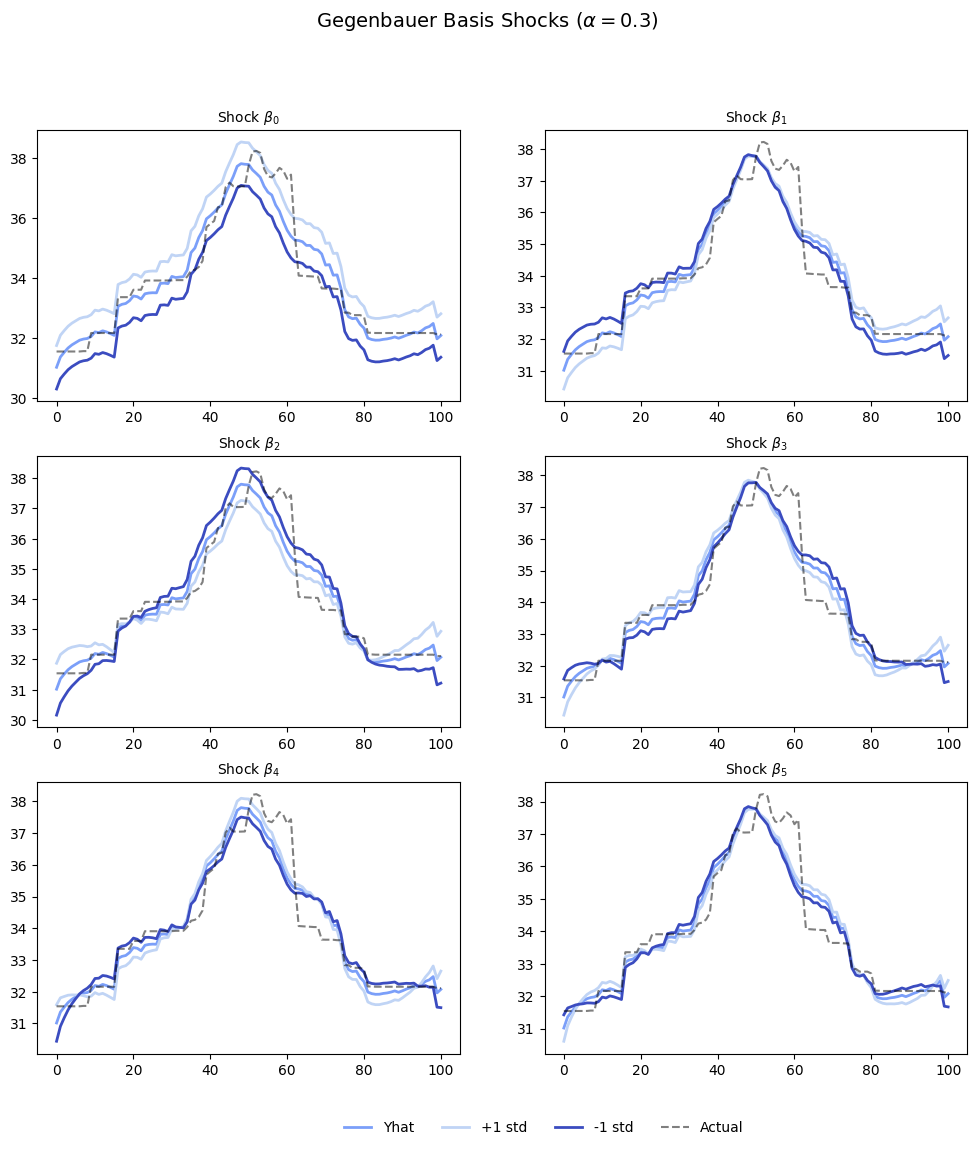

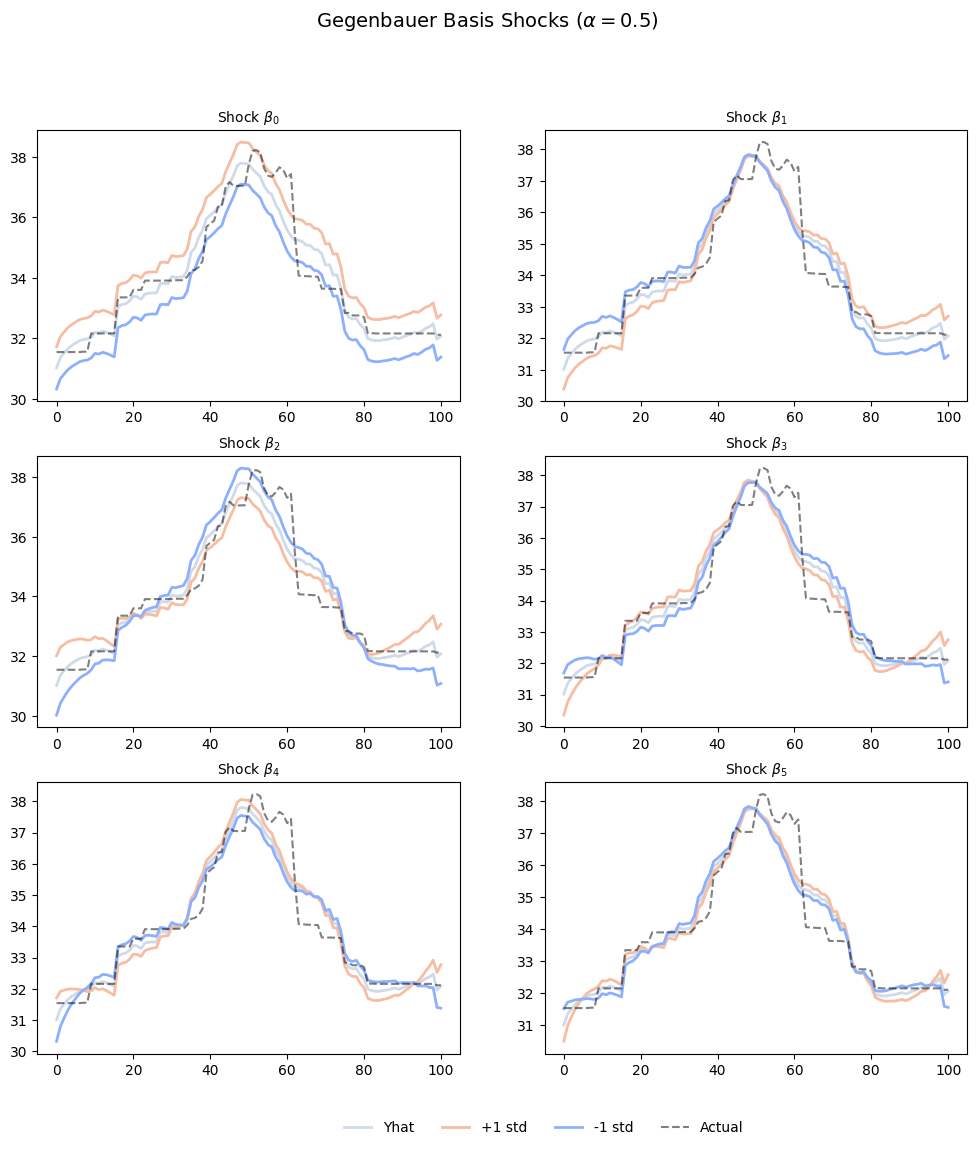

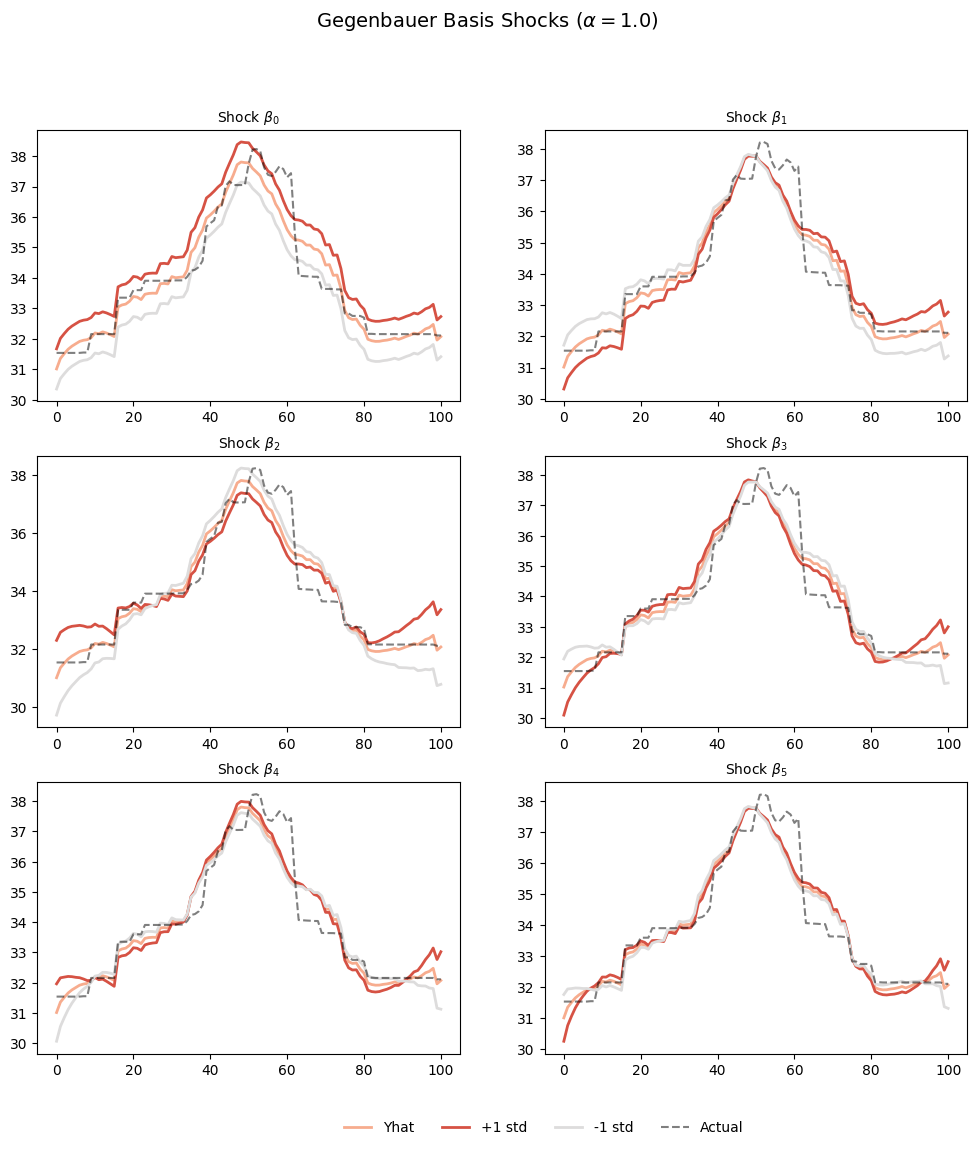

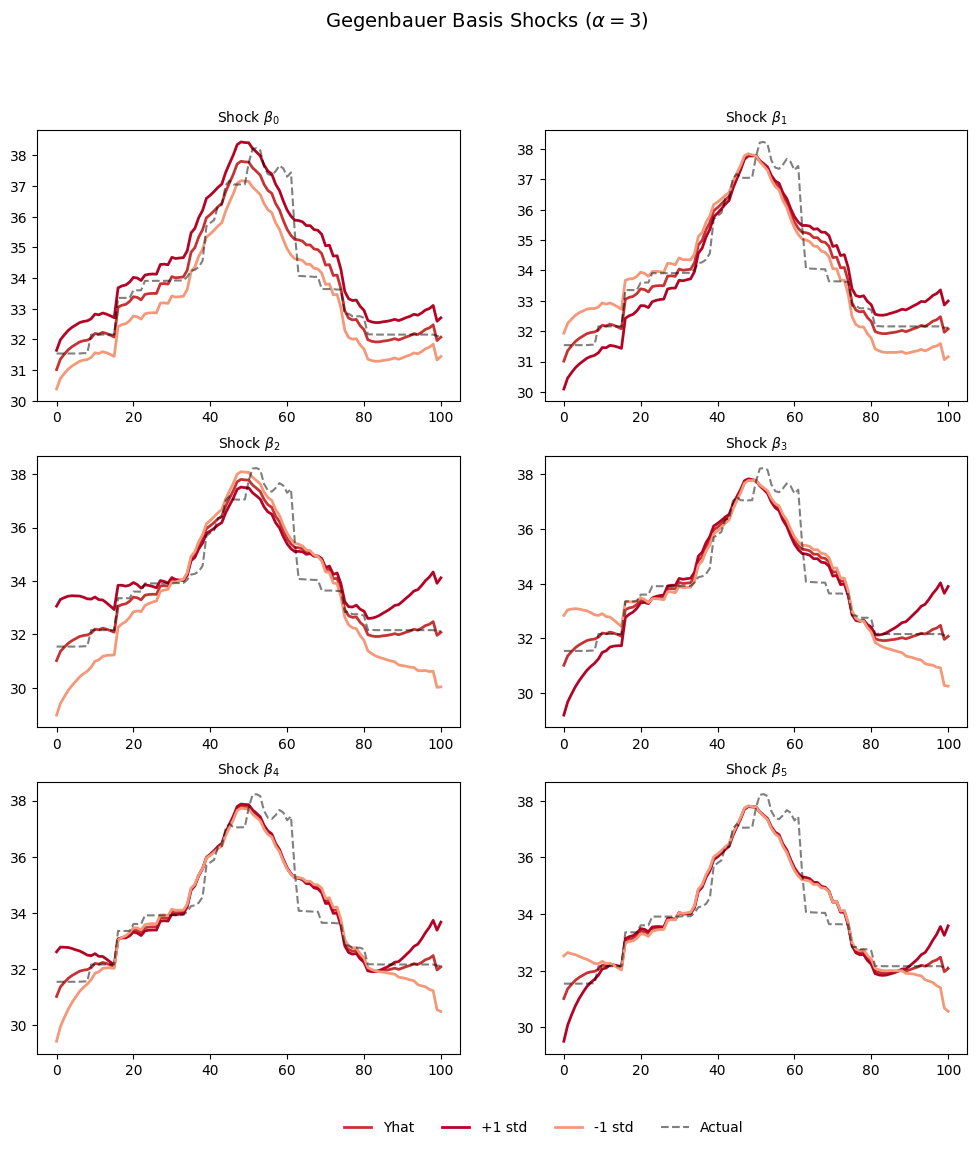

In [18]:
fig, axs = plt.subplots(3,2, figsize=(18, 8))
axs = axs.ravel()
Yh = []
for i, alpha in enumerate([0.3, 0.5, 1.0, 3]):
    gegen_scores, yhat,_,m,phi = gegenbauer_scores(Ylog_pegcentered, np.linspace(-1, 1, Ylog_pegcentered.shape[1]), deg=5, alpha=alpha)
    Yh.append(yhat[-1,:])
    plot_shocks(gegen_scores, m, phi, Ylog_pegcentered, alpha,i)
    for l in range(6):
        axs[l].plot(gegen_scores[f'Gegenbauer_{alpha}_deg{l}'], label = f'{alpha}', color = matplotlib.cm.coolwarm(np.linspace(0,1,5)[i]), lw=2)
        # axs[l].set_title(f'Gegenbauer scores through time (alpha={alpha})')
        axs[l].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y", tz=mdates.UTC))
        axs[l].xaxis.set_major_locator(plt.MaxNLocator(5))
        axs[l].set_ylabel(r'$\beta{}$'.format(i))
        
axs[-1].legend(title = 'alpha', ncols = 4, bbox_to_anchor=(.1, -0.28), frameon=False)
fig.savefig('./gegenbauer_scores_comparison.png', dpi=300, transparent = True, bbox_inches = 'tight')